# Pleasant vs Unpleasant Face Classifier

A simple image classification project using **ResNet50** to identify whether a face appears *pleasant* or *unpleasant*.
The objective of this assignment is to develop a decision system that classifies facial images into two categories (binary classification).

---


### 1. Load and Preprocess Images

We load images from two folders: `pleasant/` and `unpleasant/`, resize them to 224×224 (as expected by ResNet50), convert BGR to RGB, and assign binary labels:
- `1` for **pleasant**
- `0` for **unpleasant**
  
### 2. Train-Test Split

We use `train_test_split` from scikit-learn to divide the dataset:
- 80% for training
- 20% for testing

We use stratified sampling to ensure balanced class distribution in both sets.

### 3. Preprocess for ResNet50

We normalize the pixel values using `preprocess_input()` from Keras' ResNet50 module, to prepare the data for training.


In [1]:
import glob, os
import cv2
import numpy as np

SIZE = 224
images, labels = [], []
for dir_path in glob.glob("/kaggle/input/machine-learning/Machine Learning/train/*"):
    label = os.path.basename(dir_path)
    for img_path in glob.glob(os.path.join(dir_path, "*.jpg")):
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        img = cv2.resize(img, (SIZE, SIZE))
        # OpenCV loads BGR; Keras preprocess_input expects RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images.append(img)
        labels.append(1 if label=="pleasant" else 0) 

images = np.array(images)
labels = np.array(labels)


from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    images, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

from tensorflow.keras.applications.resnet50 import preprocess_input
x_train = preprocess_input(x_train)
x_test  = preprocess_input(x_test)


2025-05-01 18:21:08.386344: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746123668.636044      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746123668.702733      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


### 4. Visualize Sample Images 

We display five random samples from the dataset to inspect image quality and verify label correctness.  
Each image is shown with its corresponding label: **pleasant** or **unpleasant**.

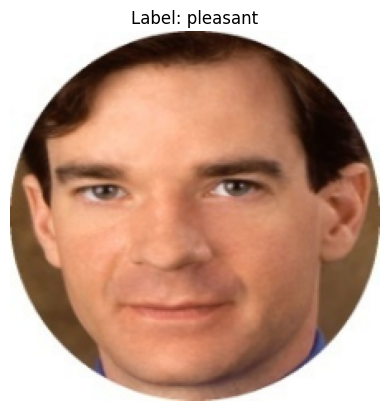

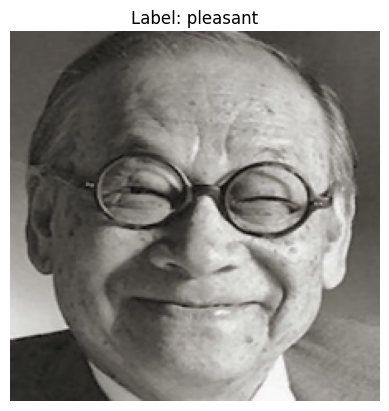

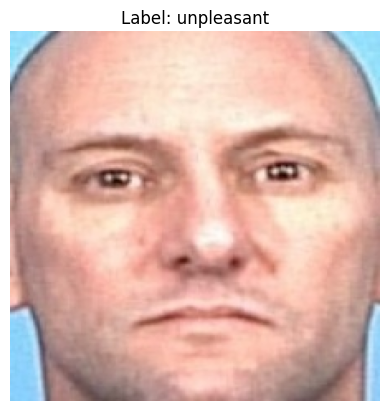

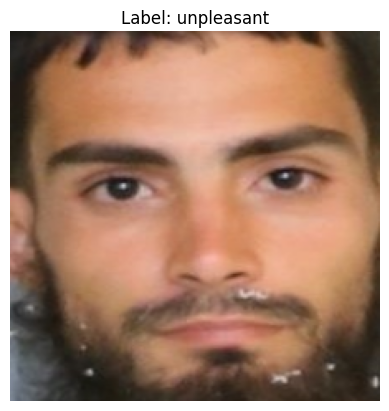

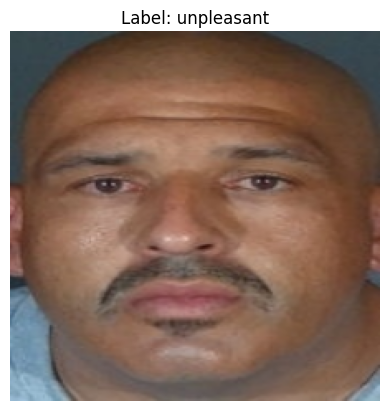

In [2]:
import matplotlib.pyplot as plt

# Show a few random images
for i in range(5):
    idx = np.random.randint(0, len(images))
    plt.imshow(images[idx])
    plt.title(f"Label: {'pleasant' if labels[idx]==1 else 'unpleasant'}")
    plt.axis('off')
    plt.show()

### 5. Build the ResNet50-based Model

We use **Transfer Learning** with a pretrained `ResNet50` model (excluding its top layers).  
The base is frozen to retain pretrained weights, and we add:

- `GlobalAveragePooling2D` to reduce dimensions (*more efficient and less prone to overfitting.*)
- `Dropout` for regularization (*helps prevent overfitting by forcing the model to not rely too heavily on specific neurons.*)
- A `Dense` output layer with `sigmoid` activation for binary classification (*outputs a single value between 0 and 1 and `sigmoid` turns it into a probability.*)

The model is compiled with:
- **Adam** optimizer
- **Binary crossentropy** loss
- Metrics: accuracy and AUC
  
At the end we print the summary of our model showcasing the number of **trainable** and **non-trainable** parameters.
Since we've frozen the base `ResNet50`, its parameters are **not trainable**, and only the added layers (GlobalAveragePooling, Dropout, Dense) will be updated during training (2,049 trainable parameters).  

In [3]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

base = ResNet50(weights="imagenet", include_top=False, input_shape=(SIZE, SIZE, 3))
# Freeze the base
for layer in base.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base.output)
x = Dropout(0.3)(x)
output = Dense(1, activation="sigmoid")(x)
model = Model(inputs=base.input, outputs=output)

model.compile(
    optimizer=Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy",tf.keras.metrics.AUC(name="auc")]
)

model.summary()

I0000 00:00:1746123685.931493      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1746123685.932173      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

### 6. Train the Model

We begin training the model with the following settings:

- `validation_split=0.1`: 10% of the training data is used for validation during training.
- Callbacks:
    - `EarlyStopping`: Monitors the validation loss and stops training early if it doesn't improve for 5 epochs, restoring the best weights. This prevents overfitting.
    - `ModelCheckpoint`: Saves the model with the best validation performance during training as `"best_resnet50.keras"`.
- Epochs: The model trains for up to 20 epochs (or fewer if early stopping is triggered).
- Batch size: Each batch contains 32 samples.

#### Fine-tuning:
After training the base model, we **unfreeze** the top 30 layers of the `ResNet50` model to fine-tune the network.  
This allows the model to adjust more complex features from the pretrained model that might be better suited for our dataset.

- **Lower Learning Rate (LR):** We reduce the learning rate to `1e-5` to make fine-tuning more subtle and avoid damaging the pretrained weights.
- The model is trained for an additional 10 epochs with the updated layers.





In [4]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint("best_resnet50.keras", save_best_only=True)
]

history = model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    callbacks=callbacks
)

# Unfreeze the top ResNet block and continue training at a lower LR
for layer in base.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy",tf.keras.metrics.AUC(name="auc")]
)

history_finetune = model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/20


I0000 00:00:1746123707.618366     100 service.cc:148] XLA service 0x798800050010 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746123707.619430     100 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1746123707.619461     100 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1746123709.020452     100 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/144 ━━━━━━━━━━━━━━━━━━━━ 40:43 17s/step - accuracy: 0.5312 - auc: 0.6465 - loss: 0.6647

I0000 00:00:1746123714.055721     100 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


144/144 ━━━━━━━━━━━━━━━━━━━━ 44s 190ms/step - accuracy: 0.5741 - auc: 0.6113 - loss: 0.7006 - val_accuracy: 0.7902 - val_auc: 0.8611 - val_loss: 0.5172
Epoch 2/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 13s 92ms/step - accuracy: 0.7108 - auc: 0.7910 - loss: 0.5529 - val_accuracy: 0.8255 - val_auc: 0.9054 - val_loss: 0.4368
Epoch 3/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 13s 94ms/step - accuracy: 0.8022 - auc: 0.8815 - loss: 0.4473 - val_accuracy: 0.8431 - val_auc: 0.9242 - val_loss: 0.3915
Epoch 4/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 14s 95ms/step - accuracy: 0.8045 - auc: 0.8869 - loss: 0.4300 - val_accuracy: 0.8608 - val_auc: 0.9337 - val_loss: 0.3605
Epoch 5/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 14s 96ms/step - accuracy: 0.8333 - auc: 0.9166 - loss: 0.3802 - val_accuracy: 0.8608 - val_auc: 0.9406 - val_loss: 0.3368
Epoch 6/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 14s 97ms/step - accuracy: 0.8471 - auc: 0.9288 - loss: 0.3542 - val_accuracy: 0.8725 - val_auc: 0.9462 - val_loss: 0.3194
Epoch 7/20
144/144 ━━━━━━━━━━━━━━━━━━━


### 7. Evaluate the Model

Finally, we evaluate the model on the test set using `model.evaluate()`.

This returns the following metrics:
- **Loss:** Binary cross-entropy loss on the test set.
- **Accuracy:** How many predictions match the true labels.
- **AUC (Area Under Curve):** Measures the model's ability to distinguish between classes, especially useful when dealing with imbalanced datasets.

The results are printed for further analysis.

In [5]:
# 7) Evaluate
loss, acc, auc = model.evaluate(x_test, y_test)
print(f"Test loss: {loss:.4f} — Test accuracy: {acc:.4f} - Test auc: {auc:.4f}")

40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 199ms/step - accuracy: 0.9674 - auc: 0.9927 - loss: 0.0919
Test loss: 0.0877 — Test accuracy: 0.9663 - Test auc: 0.9947
